# Computing Distances on the Tropical Jacobian

Yueqi Cao, *Department of Mathematics, Imperial College London*

In [8]:
import sys
from pathlib import Path

src_path = Path("../src") 
sys.path.append(str(src_path))

import mgraph
from tropdist import *
import numpy as np
import networkx as nx
import scipy.optimize as sop
import matplotlib.pyplot as plt

# set random seed for reproducibility
np.random.seed(0)

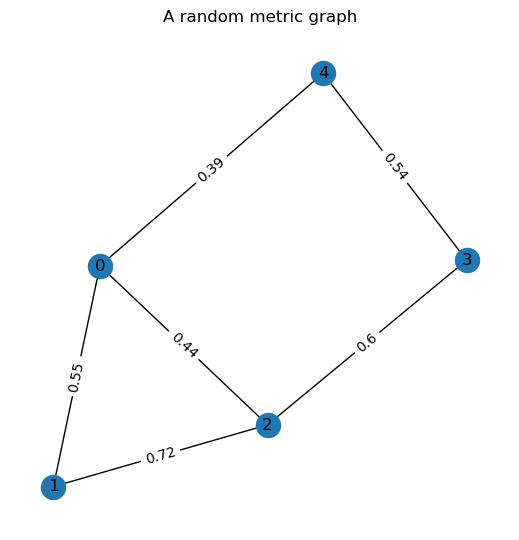

In [9]:
# Create a random metric graph
MG = generate_random_graph(5, max_edges=6)

# draw the random graph
plt.figure(figsize=(5,5))
pos = nx.spring_layout(MG)
nx.draw(MG, pos, with_labels=True)   
edge_labels = nx.get_edge_attributes(MG,'weight') 
edge_dic = nx.draw_networkx_edge_labels(MG, pos, edge_labels=edge_labels)
plt.title("A random metric graph")
plt.show()

the tropical polarization matrix is
 [[1.71 0.44]
 [0.44 1.97]]


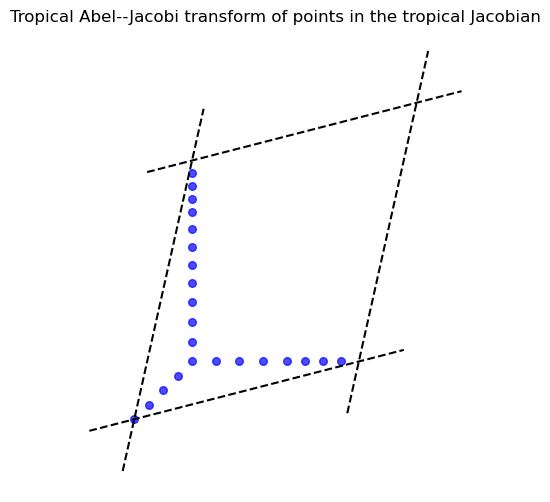

In [10]:
# compute the tropical Abel--Jacobi transform

# compute a minimal spanning tree
MST = nx.minimum_spanning_tree(MG)
# set the base point of the transform
base_point = list(MST.nodes())[0]
# compute the transform
V0 = MG.trop_transform(MST, base_point)
# sample more points from the transform
V = MG.interpolate(MST, V0, 3)
# compute the tropical polarization matrix
Q = MG.trop_polarization(MST)
print("the tropical polarization matrix is\n", Q)

# draw the tropical Abel--Jacobi transform
fig, ax = plt.subplots(figsize=(6,6))
draw_lattice_2D(Q, ax)
# translate the vectors for better visualization
Vr = translate_to_fundamental_domain(V, Q)
ax.scatter(Vr[0,:], Vr[1,:], color='blue', s=30, alpha=0.7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Tropical Abel--Jacobi transform of points in the tropical Jacobian")
plt.show()

Is Q_LLL reduced?  True
The reduced lattice is 
 [[ 1.71 -1.27]
 [ 0.44  1.53]]


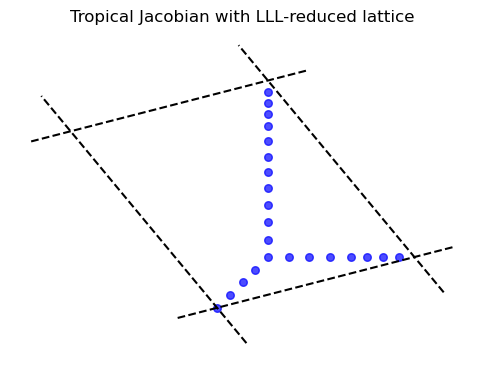

In [13]:
# compute the LLL-reduced lattice
Q_check, Q_LLL = LLL_reduced_lattice(Q)

# check if Q_LLL is indeed LLL-reduced
print("Is Q_LLL reduced? ", fp.LLL.is_reduced(Q_check))
print("The reduced lattice is \n", Q_LLL)

# draw the LLL-reduced lattice and points
fig, ax = plt.subplots(figsize=(6,6))
draw_lattice_2D(Q_LLL, ax)
Vr = translate_to_fundamental_domain(V, Q_LLL)
ax.scatter(Vr[0,:], Vr[1,:], color='blue', s=30, alpha=0.7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Tropical Jacobian with LLL-reduced lattice")
plt.show()

In [12]:
#import pyomo.environ as pyo
# import scipy.optimize as sop

# Trop_dist = np.zeros((N,N))

# for i in range(N):
#     if i%10 == 1:
#         print(i)
#     for j in range(i+1,N):
#         b = E[:,i]-E[:,j]
#         model = pyo.ConcreteModel()
#         model.x = pyo.Var(range(homology_dim), domain=pyo.Integers)
#         model.y = pyo.Var(domain=pyo.NonNegativeReals)
#         model.OBJ = pyo.Objective(expr = model.y)
#         model.con = pyo.ConstraintList()
#         for k in range(homology_dim):
#             expr1 = -model.y
#             expr2 = -model.y
#             for r in range(homology_dim):
#                 expr1 += Q[k,r]*model.x[r]
#                 expr2 += -Q[k,r]*model.x[r]
#             model.con.add(expr1<=b[k])
#             model.con.add(expr2<=-b[k])
#         result = pyo.SolverFactory("gurobi").solve(model,tee=False)
#         Trop_dist[i,j] = model.y.value

# Trop_dist = Trop_dist+Trop_dist.T